# General EDA

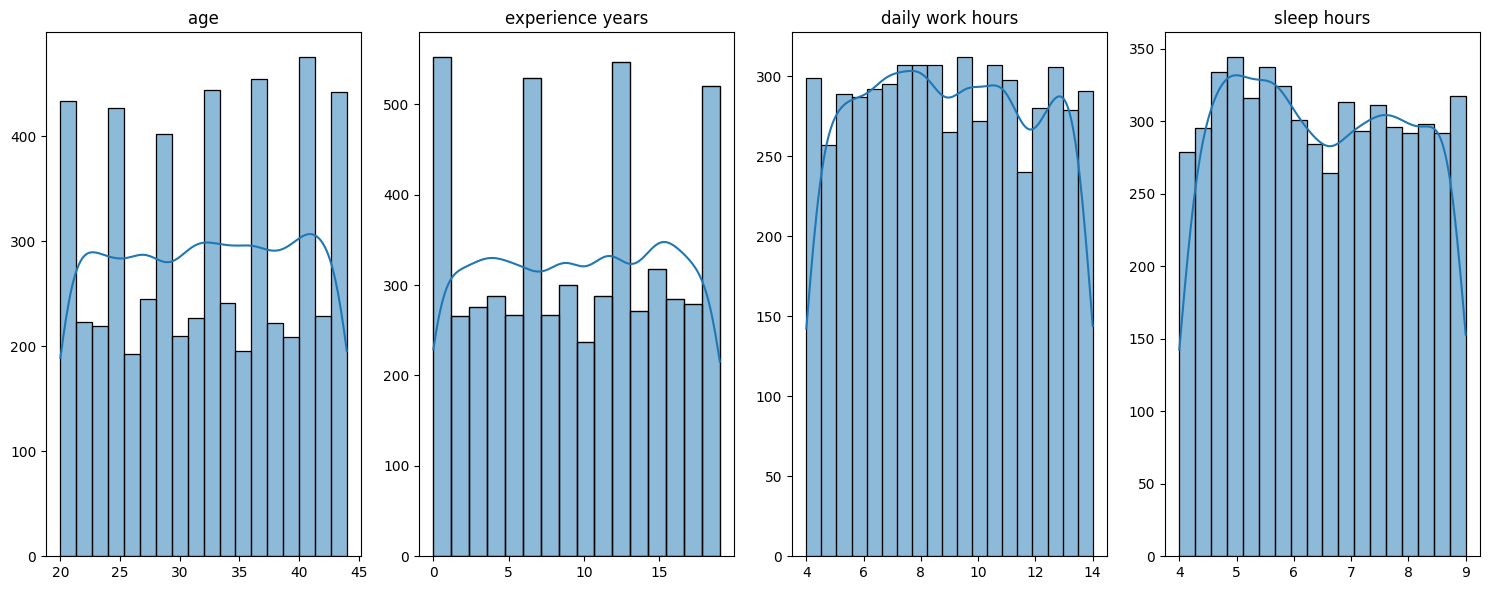

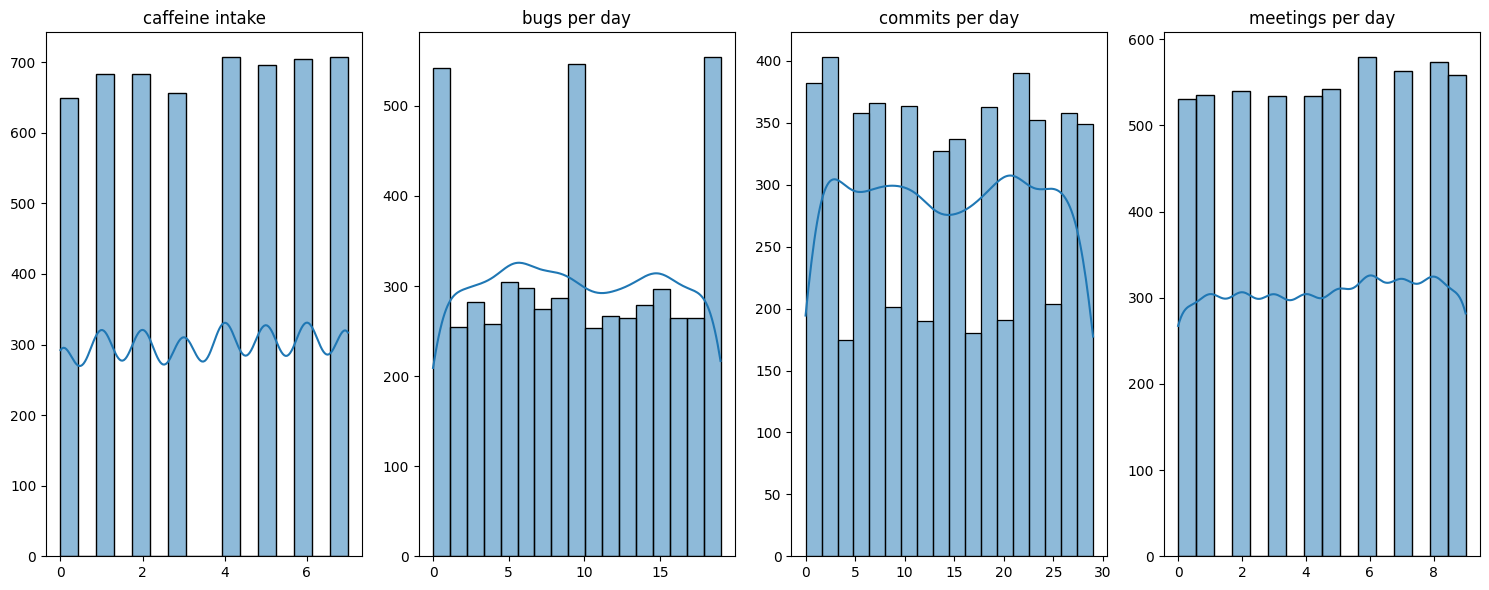

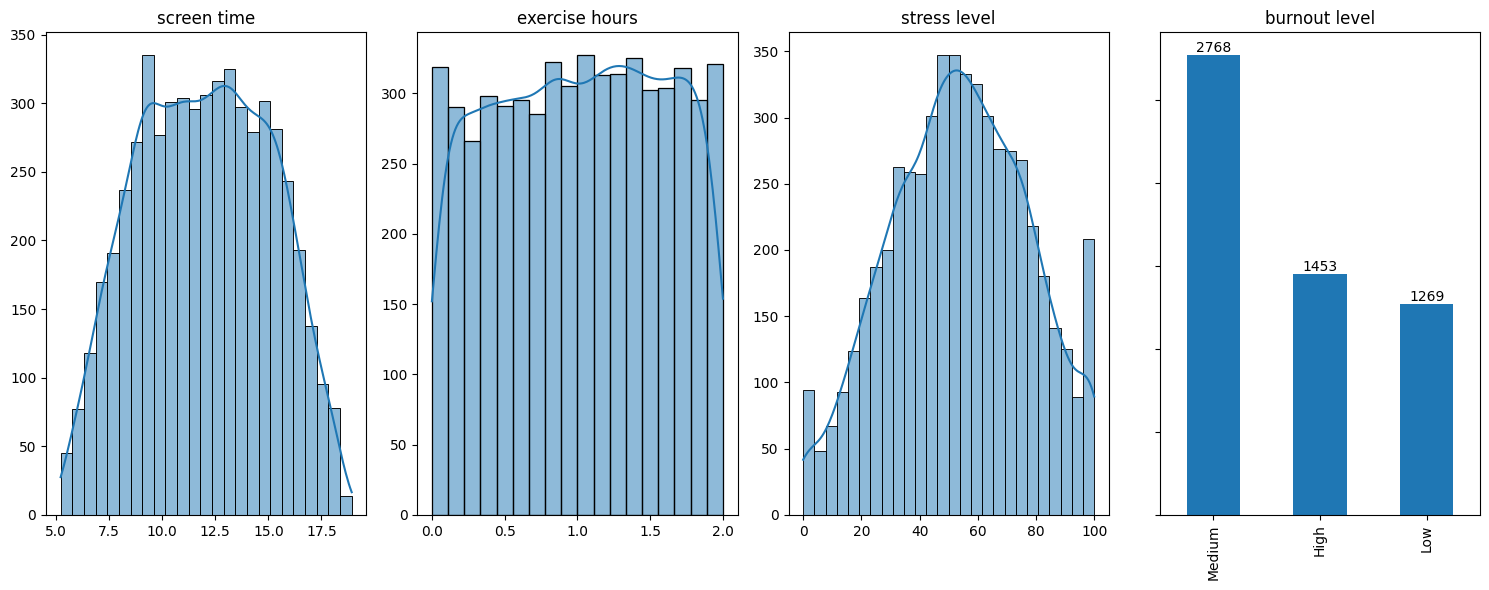

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.display import display, HTML

def bar_labels(axes, rotation=0, location="edge"):
    for container in axes.containers:
        axes.bar_label(container, label_type=location, rotation=rotation)
    axes.set_xlabel("")
    axes.set_ylabel("")
    axes.set_yticklabels(())

def training_classification():
    rfc = RandomForestClassifier()
    abc = AdaBoostClassifier()
    gbc = GradientBoostingClassifier()
    etc = ExtraTreesClassifier()
    lgr = LogisticRegression()
    svc = SVC()
    xgb = XGBClassifier()
    lgb = LGBMClassifier(verbose=-100)
    cat = CatBoostClassifier(verbose=False)

    models = [rfc, abc, gbc, etc, lgr,
             svc, xgb, lgb, cat]

    names = ["Random Forest", "Ada Boost", "Gradient Boosting", "Extra Trees", "Logistic Regression",
            "SVC", "XGBoost", "LightGBM", "Cat Boost"]

    scores = []
    cms = dict()
    reports = dict()

    sample_weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train #provide your own target name
    )

    for i, j in enumerate(names):
        models[i].fit(x_train, y_train, sample_weight=sample_weights)
        pred = models[i].predict(x_test)
        scores += [accuracy_score(pred, y_test)]
        cms[j] = confusion_matrix(pred, y_test)
        reports[j] = classification_report(pred, y_test)

    dt = pd.DataFrame({"scores": scores}, index=names)
    dt = dt.sort_values("scores", ascending=False)

    dt["scores"] = dt["scores"]*100
    dt["scores"] = round(dt["scores"], 2)

    fig, axes = plt.subplots(figsize=(15, 6))

    dt["scores"].plot(kind="bar", ax=axes)
    bar_labels(axes)

    index = 0

    for _ in range(3):
        fig, axes = plt.subplots(ncols=3, figsize=(15, 6))
        for i in range(3):
            sns.heatmap(cms[dt.index[index]], annot=True, ax=axes[i])
            axes[i].set_title("{}: {}%".format(dt.index[index], dt.iloc[index, 0]))
            index += 1
        plt.tight_layout()
        plt.show()

    for i in dt.index:
        print("*"*30)
        print("\n")
        print(i)
        print("\n")
        print(reports[i])

df = pd.read_csv("/kaggle/input/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples/developer_burnout_dataset_7000.csv")

df.dropna(inplace=True)

cats = [i for i in df.columns if df[i].dtype == 'O' or df[i].nunique() <= 2]
nums = [i for i in df.columns if i not in cats]

index = 0

for _ in [4, 4, 4]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df[df.columns[index]].value_counts()[:10].plot(kind="bar", ax=axes[i])
            bar_labels(axes[i])
        else:
            sns.histplot(df, x=df.columns[index], kde=True, ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
        axes[i].set_title(df.columns[index].replace('_', ' '))

        index += 1
    plt.tight_layout()
    plt.show()

# Different burnout risks - common features

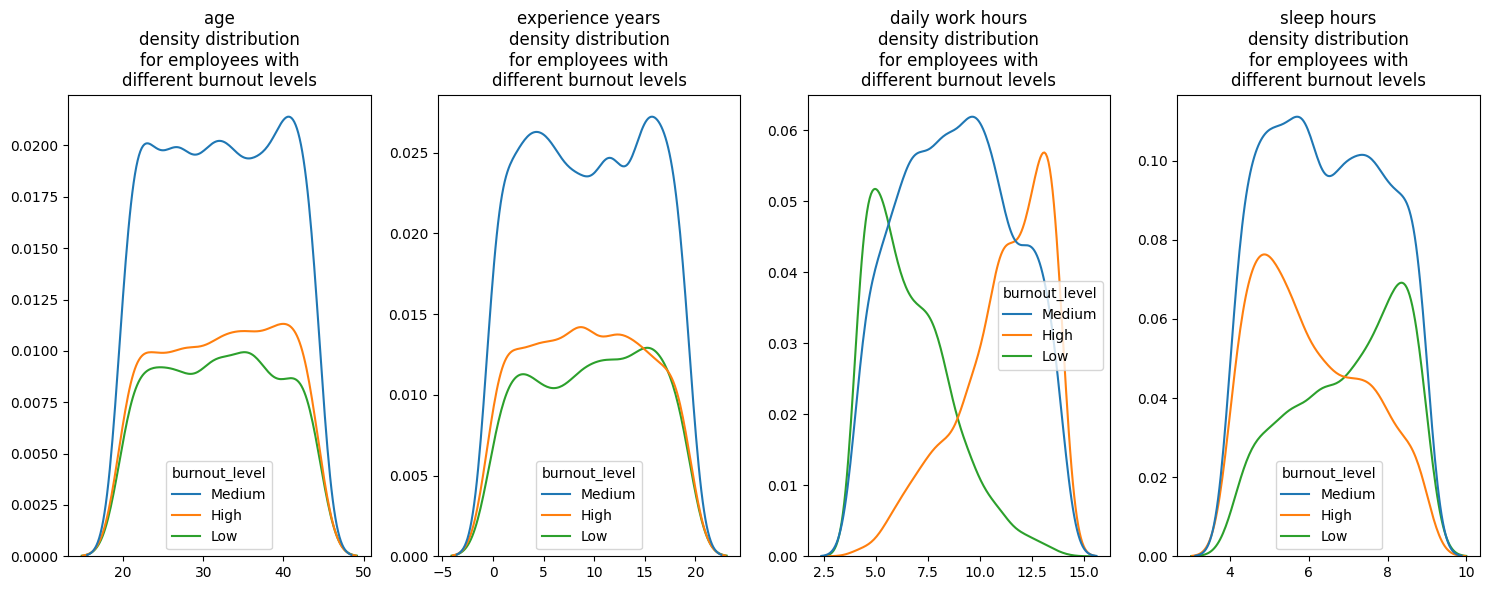

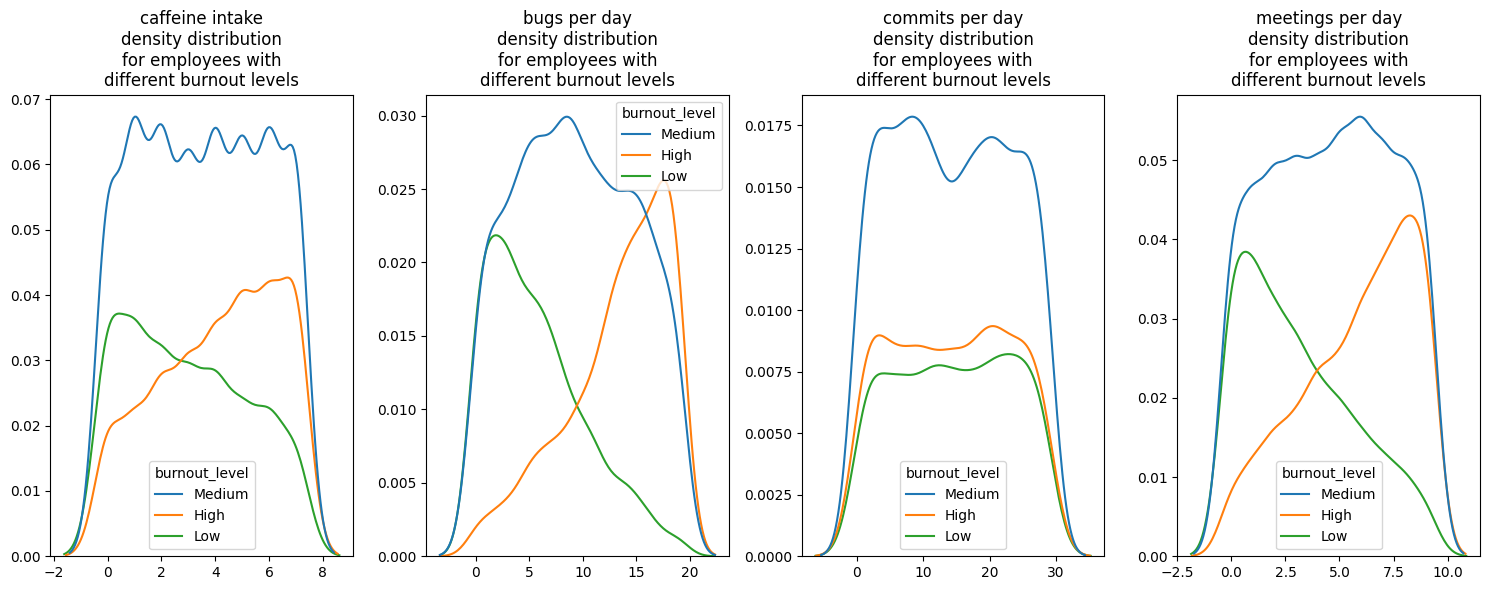

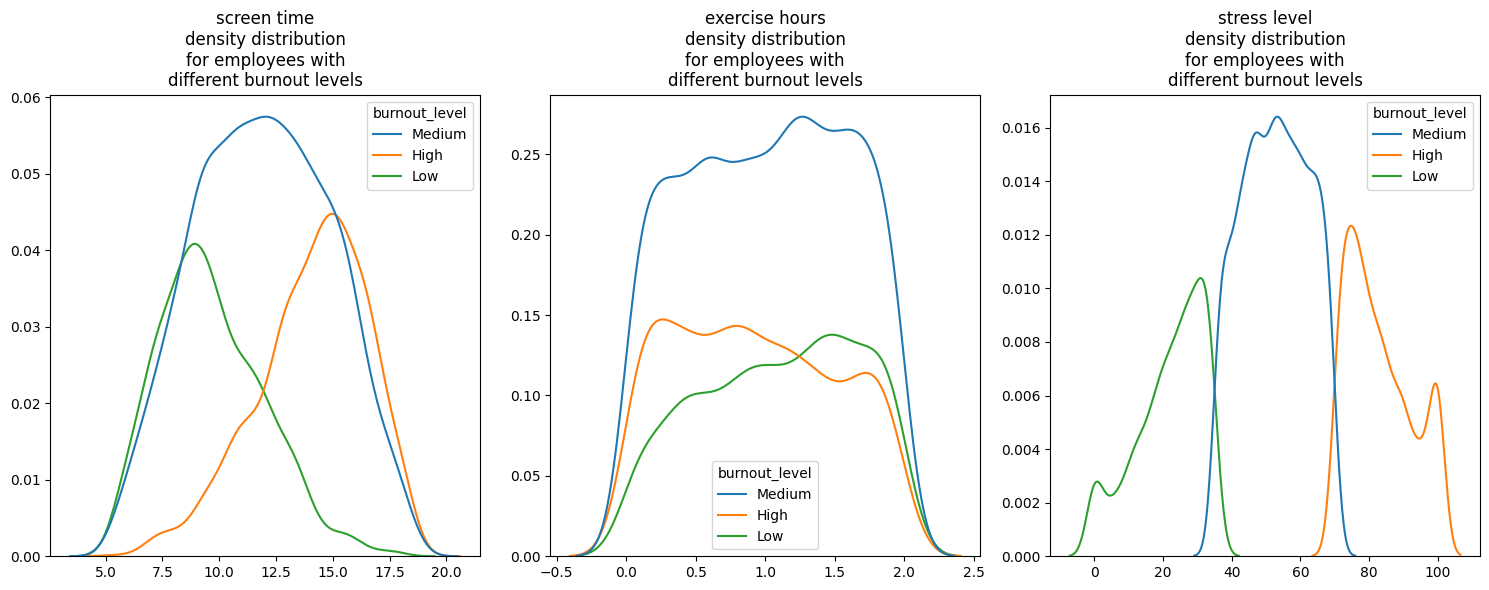

In [2]:
index = 0
    
for _ in [4, 4, 3]:
    fig, axes = plt.subplots(ncols=_, figsize=(15, 6))
    for i in range(_):
        if df.columns[index] in cats:
            df.groupby(df.columns[index])[cats[-1]].value_counts()[:10].unstack().plot(kind="bar", stacked=True, ax=axes[i])
            bar_labels(axes[i], 0, "center")
            axes[i].set_title("Count of {}\nfor employees with\ndifferent burnout levels".format(df.columns[index].replace('_', ' ')))
        else:
            sns.kdeplot(df, x=df.columns[index], hue=df.columns[-1], ax=axes[i])
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")
            axes[i].set_title("{}\ndensity distribution\nfor employees with\ndifferent burnout levels".format(df.columns[index].replace('_', ' ')))
        index += 1
    plt.tight_layout()
    plt.show()

# ML algorithms performance in detecting Burnout level in employees

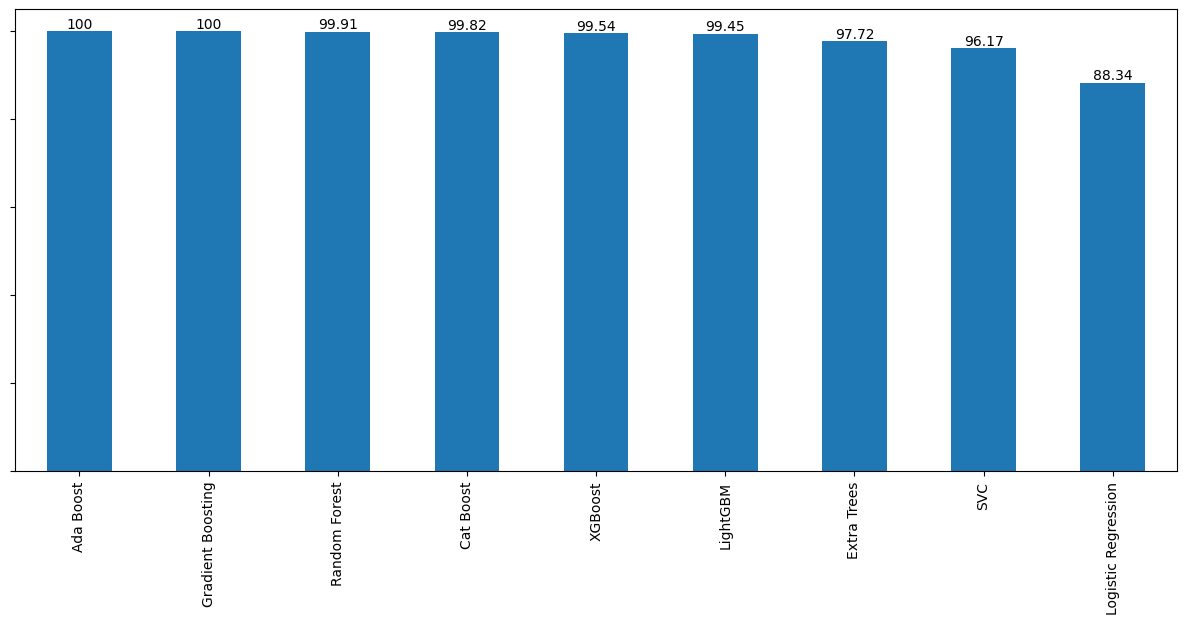

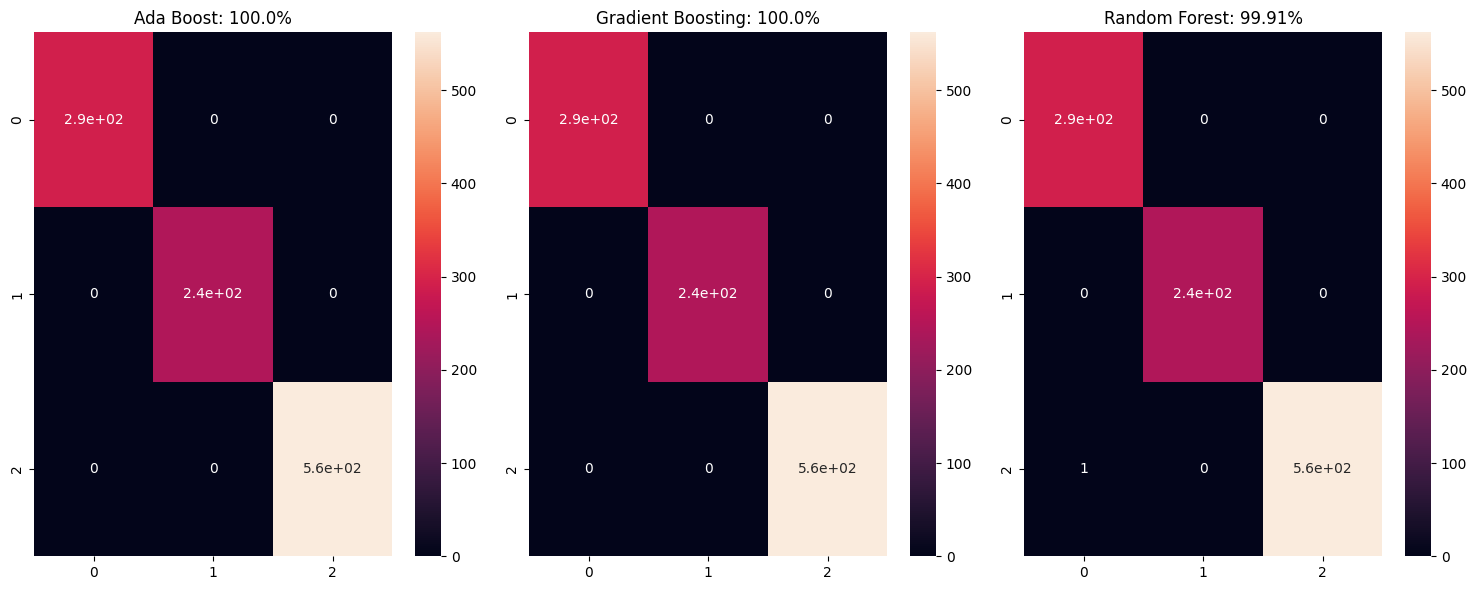

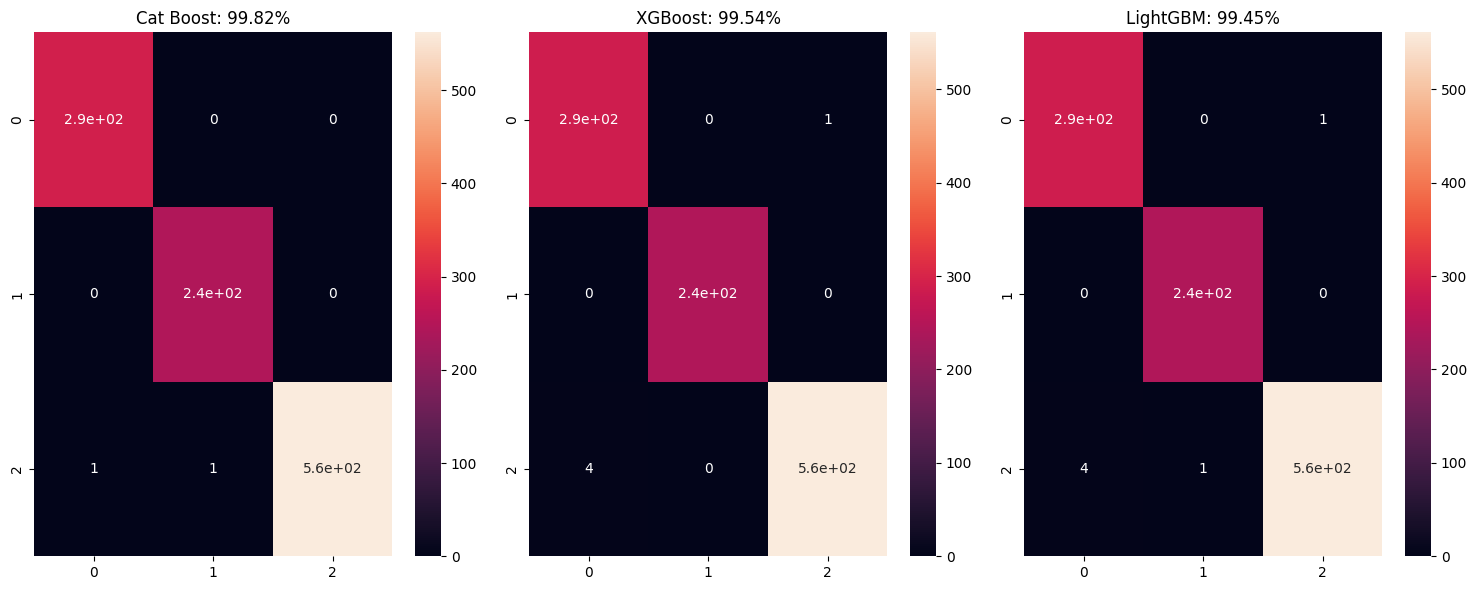

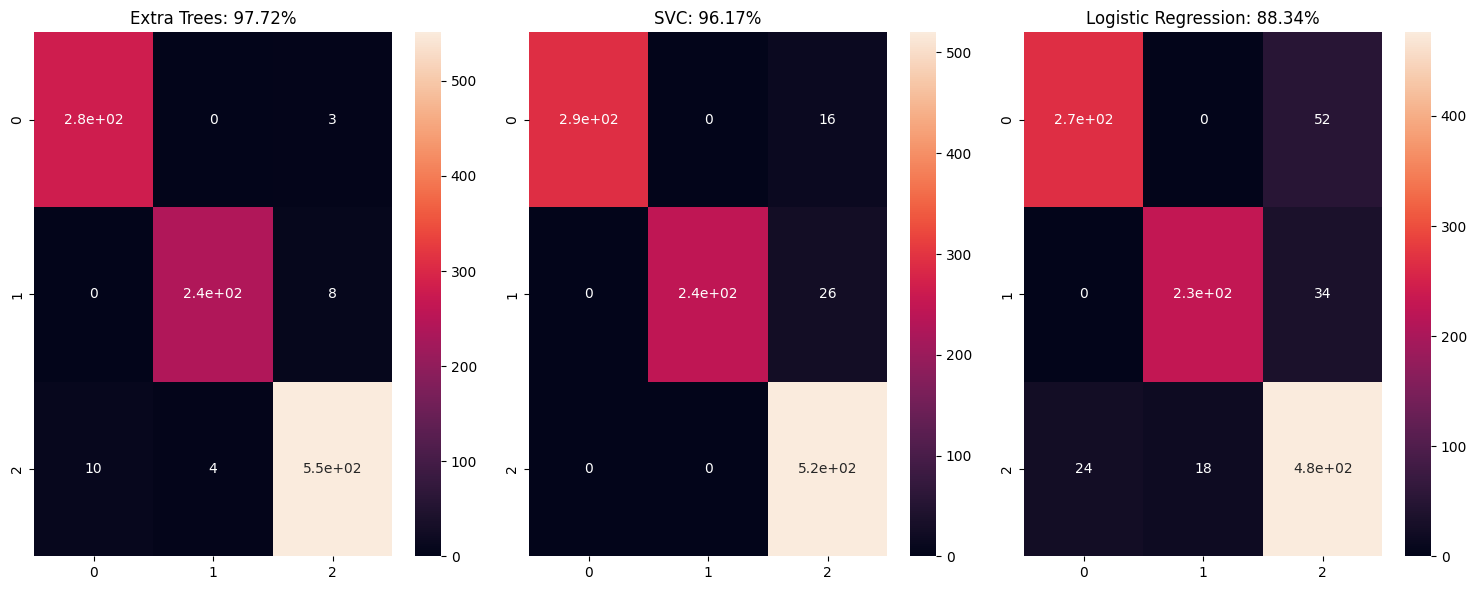

******************************


Ada Boost


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       1.00      1.00      1.00       245
           2       1.00      1.00      1.00       562

    accuracy                           1.00      1098
   macro avg       1.00      1.00      1.00      1098
weighted avg       1.00      1.00      1.00      1098

******************************


Gradient Boosting


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       1.00      1.00      1.00       245
           2       1.00      1.00      1.00       562

    accuracy                           1.00      1098
   macro avg       1.00      1.00      1.00      1098
weighted avg       1.00      1.00      1.00      1098

******************************


Random Forest


              precision    recall  f1-score   support

           0       1.00      1.00   

In [3]:
for i in cats:
    if df[i].dtype == 'O':
        df[i] = LabelEncoder().fit_transform(df[i].values)

x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

training_classification()